In [2]:
import numpy as np

# ----- Parameters -----
BUDGET = 50_000

# ----- Functions -----
def research(x):
    return 200_000 * np.log(1 + x) / np.log(1 + 100)

def scale(x):
    return 7 * x / 100

# This is ranked-based depending on what other people allocate
# def speed_best_case():
#     # assume rank 1 (best possible outcome)
#     return 0.9
def speed(x):
    return 0.8 * x / 100 + 0.1


def budget_used(r, s, sp):
    return BUDGET * (r + s + sp) / 100

def pnl(r, s, sp):
    R = research(r)
    S = scale(s)
    Sp = speed(sp)
    return (R * S * Sp) - budget_used(r, s, sp)

# ----- Brute force search -----
best_pnl = -np.inf
best_alloc = None

# resolution = 1% steps (can refine later)
for r in range(101):
    for s in range(101 - r):
        for sp in range(101 - r - s):
            value = pnl(r, s, sp)
            if value > best_pnl:
                best_pnl = value
                best_alloc = (r, s, sp)

# ----- Output -----
print("Best Allocation (Research, Scale, Speed):", best_alloc)
print("Max PnL:", best_pnl)

Best Allocation (Research, Scale, Speed): (16, 48, 36)
Max PnL: 110065.31395662151


In a vacuum where speed is linear, the optimal appears to be 36 percent

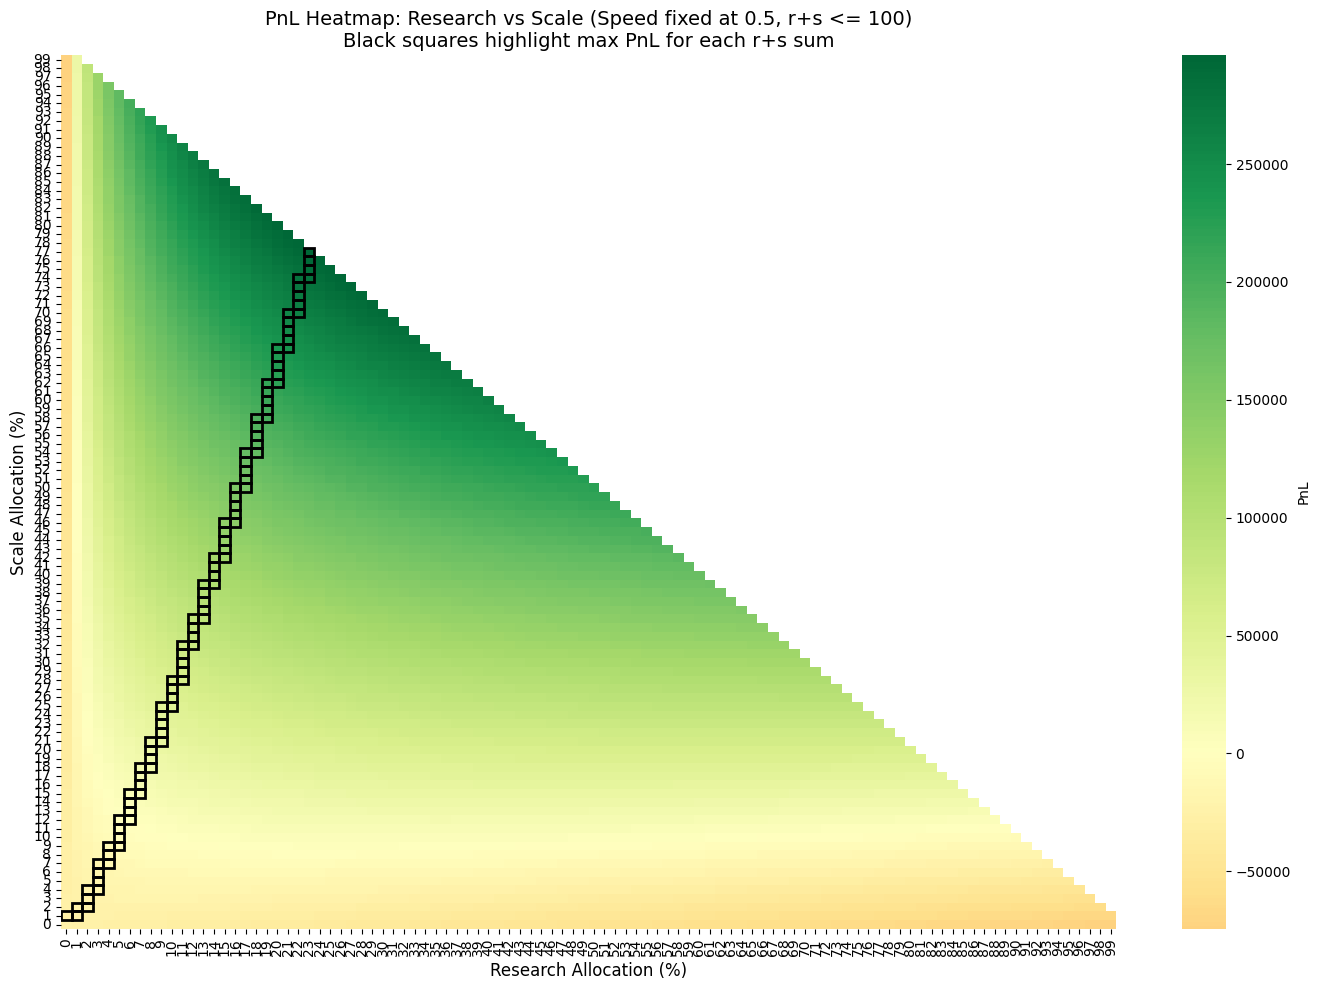


Best Allocation (Research, Scale, Speed): (np.int64(23), np.int64(77), 50)
Max PnL (constrained): 296164.9583811858


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Speed fixed at 0.5 corresponds to sp=50
# (0.5 = 0.8 * 50 / 100 + 0.1)
sp_fixed = 50

# Create grid for research and scale (0-99)
research_vals = np.arange(0, 100)
scale_vals = np.arange(0, 100)

# Create 2D array for PnL values
pnl_grid = np.full((len(scale_vals), len(research_vals)), np.nan)

# Fill grid only for combinations where research + scale >= 100
for i, s in enumerate(scale_vals):
    for j, r in enumerate(research_vals):
        if r + s <= 100:
            pnl_grid[i, j] = pnl(r, s, sp_fixed)

# Create heatmap (flip y-axis so 0 is at bottom)
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(pnl_grid[::-1], 
            xticklabels=research_vals, 
            yticklabels=scale_vals[::-1], 
            cmap='RdYlGn', 
            center=0,
            cbar_kws={'label': 'PnL'},
            ax=ax,
            vmin=pnl_grid[~np.isnan(pnl_grid)].min(),
            vmax=pnl_grid[~np.isnan(pnl_grid)].max())

# Add highlighting for max PnL for each research+scale sum
# Create a copy of grid for tracking max values per sum
for total_sum in range(1, 101):
    max_pnl_for_sum = -np.inf
    max_pos = None
    
    # Find max PnL for this sum
    for r in range(100):
        s = total_sum - r
        if 0 <= s < 100:
            val = pnl(r, s, sp_fixed)
            if val > max_pnl_for_sum:
                max_pnl_for_sum = val
                max_pos = (r, s)
    
    # Highlight the max cell for this sum with a black square
    if max_pos is not None:
        r_idx, s_idx = max_pos
        # Adjust for flipped y-axis
        y_idx = 99 - s_idx
        ax.add_patch(plt.Rectangle((r_idx, y_idx), 1, 1, fill=False, edgecolor='black', lw=2))

ax.set_xlabel('Research Allocation (%)', fontsize=12)
ax.set_ylabel('Scale Allocation (%)', fontsize=12)
ax.set_title('PnL Heatmap: Research vs Scale (Speed fixed at 0.5, r+s <= 100)\nBlack squares highlight max PnL for each r+s sum', fontsize=14)

plt.tight_layout()
plt.show()

# Also find the best allocation in this constrained space
valid_indices = ~np.isnan(pnl_grid)
best_idx = np.nanargmax(pnl_grid)
best_row, best_col = np.unravel_index(best_idx, pnl_grid.shape)
best_r = research_vals[best_col]
best_s = scale_vals[best_row]
best_pnl_constrained = pnl_grid[best_row, best_col]

print(f"\nBest Allocation (Research, Scale, Speed):", (best_r, best_s, sp_fixed))
print(f"Max PnL (constrained):", best_pnl_constrained)

https://github.com/chrispyroberts/imc-prosperity-3

Shoutout these guys.

Prosperity 3 round 3 manual showed a parabolic shape, and that the optimal bid was around 285 and the average ended up being just above at 286. Although for prosperity 4 is based on rank, so by examining their graph I would put the median slightly higher at right about 290. Eyeballing again I would say that about 40 percent of orders was at this average/median zone

Prosperity 3 round 4 manual showed a game theory optimal strategy of which of 10 containers to take to get the most money

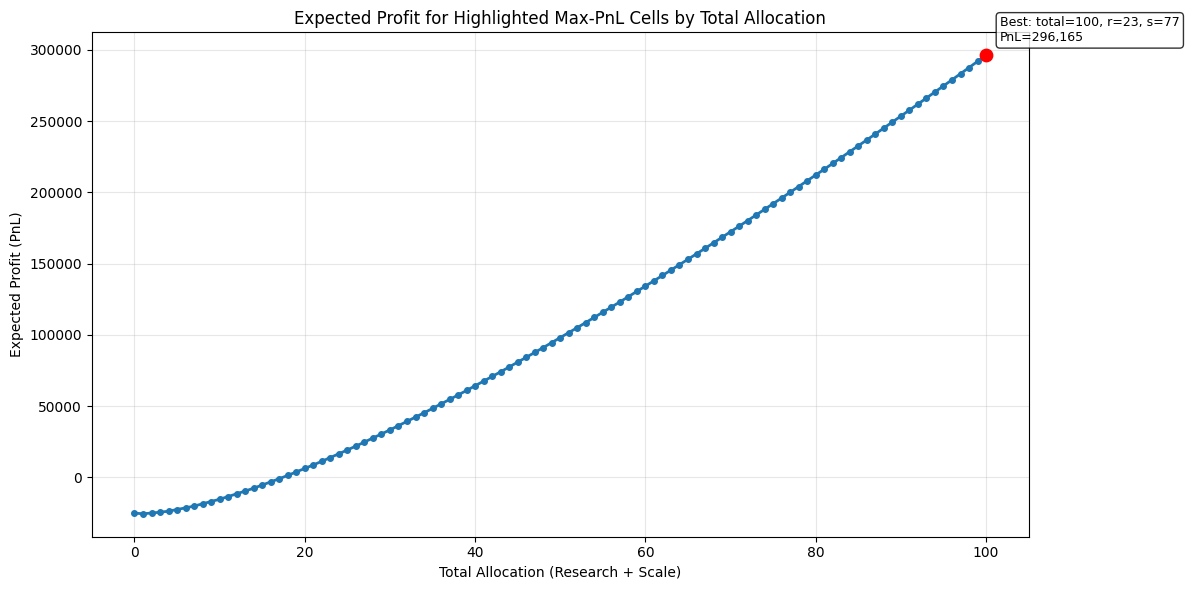

Sample highlighted points (total, research, scale, pnl):
(  0,  0,  0, -25,000.00)
( 11,  4,  7, -13,412.16)
( 22,  7, 15, 11,310.00)
( 33,  9, 24, 42,318.89)
( 44, 12, 32, 77,492.67)
( 55, 14, 41, 115,905.22)
( 66, 16, 50, 156,864.31)
( 77, 19, 58, 200,039.66)
( 88, 21, 67, 245,119.40)
(100, 23, 77, 296,164.96)


In [4]:
# Expected profit for each highlighted cell (max PnL for each r+s total)
# Uses the same constraints as above: r,s in [0, 99], speed fixed at 0.5 (sp=50)

totals = []
max_profits = []
best_points = []

for total_sum in range(0, 101):
    best_val = -np.inf
    best_pair = None

    for r in range(100):
        s = total_sum - r
        if 0 <= s < 100:
            val = pnl(r, s, sp_fixed)
            if val > best_val:
                best_val = val
                best_pair = (r, s)

    if best_pair is not None:
        totals.append(total_sum)
        max_profits.append(best_val)
        best_points.append(best_pair)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(totals, max_profits, marker='o', linewidth=2, markersize=4)
ax.set_xlabel('Total Allocation (Research + Scale)')
ax.set_ylabel('Expected Profit (PnL)')
ax.set_title('Expected Profit for Highlighted Max-PnL Cells by Total Allocation')
ax.grid(True, alpha=0.3)

peak_idx = int(np.argmax(max_profits))
peak_total = totals[peak_idx]
peak_profit = max_profits[peak_idx]
peak_r, peak_s = best_points[peak_idx]

ax.scatter([peak_total], [peak_profit], color='red', s=80, zorder=5)
ax.annotate(
    f'Best: total={peak_total}, r={peak_r}, s={peak_s}\nPnL={peak_profit:,.0f}',
    xy=(peak_total, peak_profit),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

print('Sample highlighted points (total, research, scale, pnl):')
for idx in np.linspace(0, len(totals) - 1, 10, dtype=int):
    r, s = best_points[idx]
    print(f'({totals[idx]:3d}, {r:2d}, {s:2d}, {max_profits[idx]:,.2f})')

I am going to do an iterative approach.

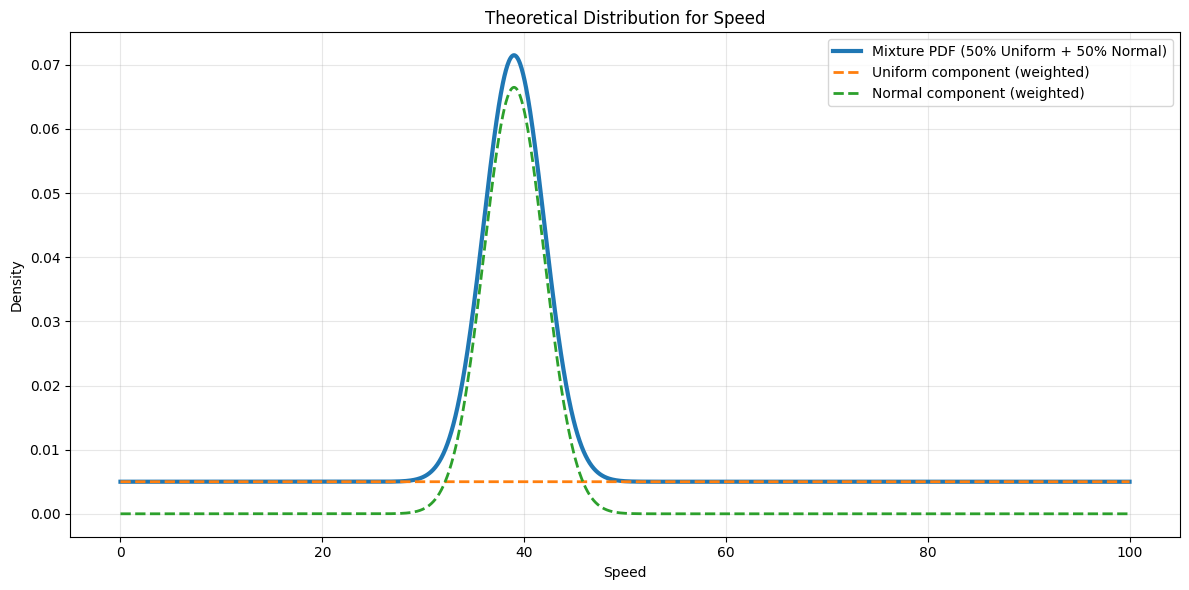

Approximate total probability mass on [0,100]: 1.000000


C:\Users\tolan\AppData\Local\Temp\ipykernel_8608\2974891487.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(mixture_pdf, x)


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Theoretical speed distribution:
# 50% Uniform(0, 100) + 50% Normal(mean=39, sd=3)
mu = 39
sigma = 3
w_uniform = 0.5
w_normal = 0.5

x = np.linspace(0, 100, 2001)

# Uniform PDF on [0, 100]
uniform_pdf = np.where((x >= 0) & (x <= 100), 1 / 100, 0.0)

# Normal PDF
normal_pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Mixture PDF
mixture_pdf = w_uniform * uniform_pdf + w_normal * normal_pdf

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, mixture_pdf, linewidth=3, label='Mixture PDF (50% Uniform + 50% Normal)')
ax.plot(x, w_uniform * uniform_pdf, '--', linewidth=2, label='Uniform component (weighted)')
ax.plot(x, w_normal * normal_pdf, '--', linewidth=2, label='Normal component (weighted)')

ax.set_title('Theoretical Distribution for Speed')
ax.set_xlabel('Speed')
ax.set_ylabel('Density')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Optional sanity check: approximate integral should be near 1
area = np.trapz(mixture_pdf, x)
print(f'Approximate total probability mass on [0,100]: {area:.6f}')

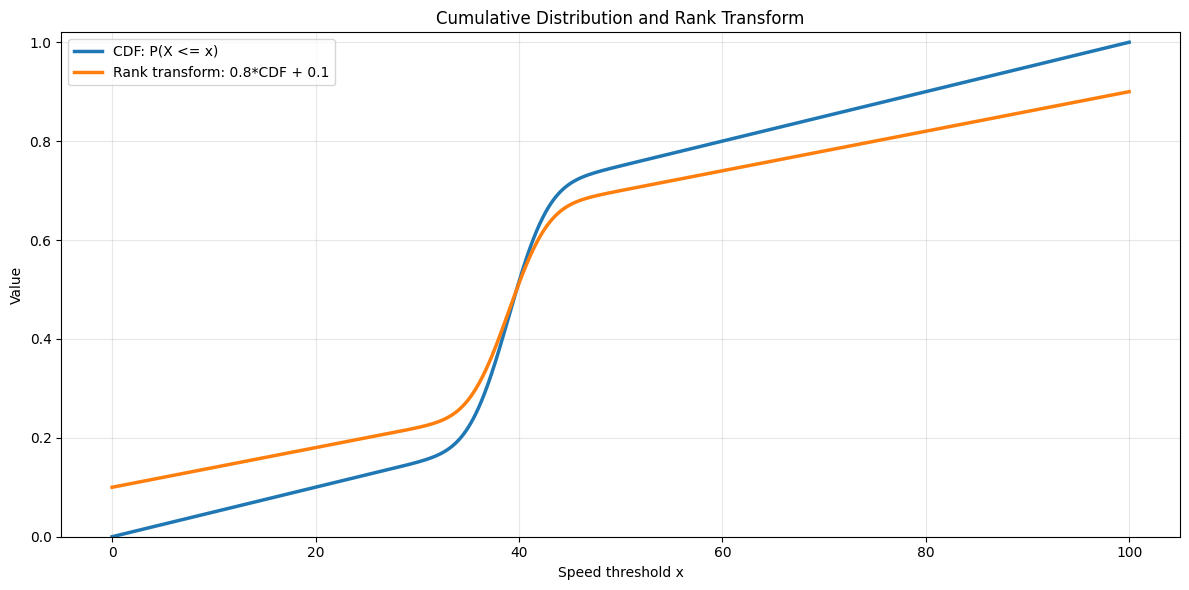

x=30.0: CDF=0.1507, rank=0.2205
x=35.0: CDF=0.2206, rank=0.2765
x=39.0: CDF=0.4450, rank=0.4560
x=43.0: CDF=0.6694, rank=0.6355
x=50.0: CDF=0.7499, rank=0.7000
CDF end value at x=100: 1.000000
Rank end value at x=100: 0.900000


In [6]:
# Cumulative integral of the speed distribution (CDF)
# Transform to rank score: 0.8 * CDF + 0.1

def rank_score_from_cdf(cdf_values):
    return 0.8 * cdf_values + 0.1


dx = x[1] - x[0]

# CDF via cumulative trapezoid rule (numpy-only)
cdf = np.empty_like(mixture_pdf)
cdf[0] = 0.0
cdf[1:] = np.cumsum(0.5 * (mixture_pdf[:-1] + mixture_pdf[1:]) * dx)
cdf = np.clip(cdf, 0.0, 1.0)

rank_score = rank_score_from_cdf(cdf)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, cdf, linewidth=2.5, label='CDF: P(X <= x)')
ax.plot(x, rank_score, linewidth=2.5, label='Rank transform: 0.8*CDF + 0.1')

ax.set_title('Cumulative Distribution and Rank Transform')
ax.set_xlabel('Speed threshold x')
ax.set_ylabel('Value')
ax.set_ylim(0.0, 1.02)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

for threshold in [30, 35, 39, 43, 50]:
    idx = np.argmin(np.abs(x - threshold))
    print(f'x={x[idx]:.1f}: CDF={cdf[idx]:.4f}, rank={rank_score[idx]:.4f}')

print(f'CDF end value at x=100: {cdf[-1]:.6f}')
print(f'Rank end value at x=100: {rank_score[-1]:.6f}')

In [7]:
# Reusable optimizer for different speed() functions

def pnl_with_speed(r, s, sp, speed_fn):
    R = research(r)
    S = scale(s)
    Sp = speed_fn(sp)
    return (R * S * Sp) - budget_used(r, s, sp)


def optimize_bundle(speed_fn, max_total=100, exact_total=False):
    """
    Brute-force search for optimal (research, scale, speed allocation).

    Args:
        speed_fn: function that maps speed allocation percent -> speed multiplier
        max_total: allocation cap (default 100)
        exact_total: if True, enforce r+s+sp == max_total

    Returns:
        (best_alloc, best_pnl)
    """
    best_value = -np.inf
    best_alloc = None

    for r in range(max_total + 1):
        for s in range(max_total + 1 - r):
            for sp in range(max_total + 1 - r - s):
                if exact_total and (r + s + sp != max_total):
                    continue

                value = pnl_with_speed(r, s, sp, speed_fn)
                if value > best_value:
                    best_value = value
                    best_alloc = (r, s, sp)

    return best_alloc, best_value


# Example usage with current speed() function
best_alloc_fn, best_pnl_fn = optimize_bundle(speed)
print('Best Allocation (Research, Scale, Speed):', best_alloc_fn)
print('Max PnL:', best_pnl_fn)

# Example for swapping speed functions:
# def speed_alt(x):
#     return 0.8 * (0.5 * x / 100 + 0.1) + 0.1
# optimize_bundle(speed_alt)

Best Allocation (Research, Scale, Speed): (16, 48, 36)
Max PnL: 110065.31395662151


Best Allocation (Research, Scale, Speed) - alt mixture: (15, 44, 41)
Max PnL - alt mixture: 237762.2531760221
x=0: cdf=0.0500, cdf_rank=0.1400
x=39: cdf=0.7838, cdf_rank=0.7270
x=50: cdf=0.9287, cdf_rank=0.8430
x=80: cdf=0.9600, cdf_rank=0.8680
x=100: cdf=1.0000, cdf_rank=0.9000


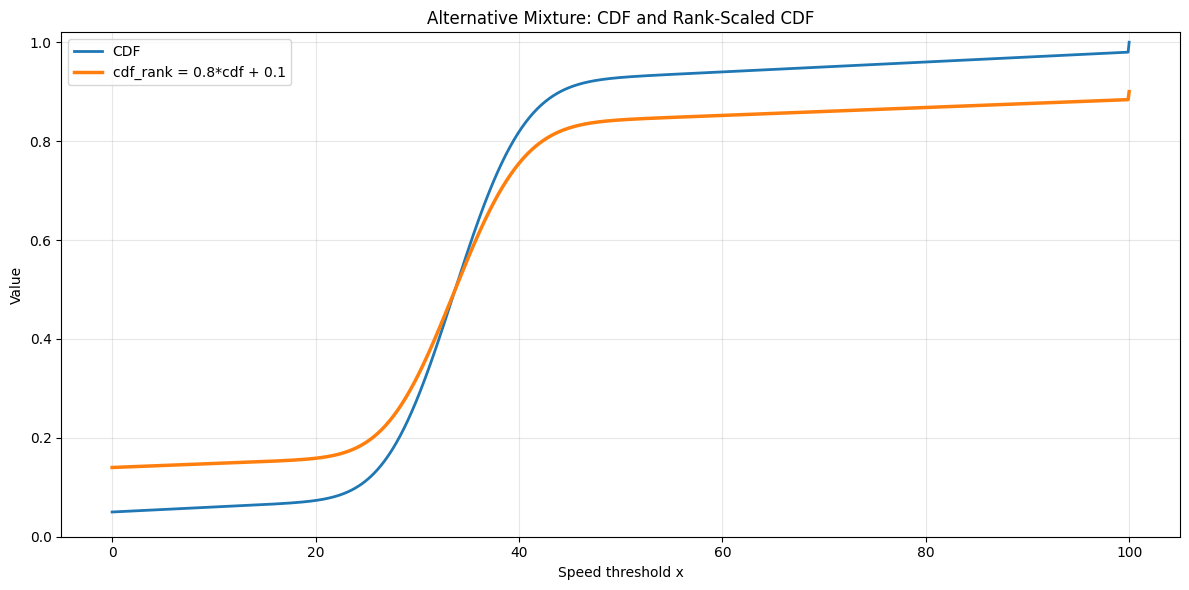

In [14]:
import math

# Alt speed model:
def speed_alt_mixture_cdf(x, mu=33, sigma=5):
    x = float(x)

    # CDF components
    uniform_cdf = min(max(x, 0.0), 100.0) / 100.0
    normal_cdf_1 = 0.5 * (1.0 + math.erf((x - mu) / (sigma * math.sqrt(2.0))))
    normal_cdf_2 = 0.5 * (1.0 + math.erf((x - 38) / (5 * math.sqrt(2.0))))
    mass_at_0_cdf = 1.0 if x >= 0.0 else 0.0
    mass_at_50_cdf = 1.0 if x >= 50.0 else 0.0
    mass_at_100_cdf = 1.0 if x >= 100.0 else 0.0

    cdf = (
        0.10 * uniform_cdf
        + 0.05 * mass_at_0_cdf
        + 0.00 * mass_at_50_cdf
        + 0.02 * mass_at_100_cdf
        + 0.70 * normal_cdf_1
        + 0.13 * normal_cdf_2

    )
    return min(max(cdf, 0.0), 1.0)


def speed_alt_mixture(x):
    # Always use the current defaults/body from speed_alt_mixture_cdf
    cdf = speed_alt_mixture_cdf(x)
    cdf_rank = 0.8 * cdf + 0.1
    return cdf_rank


best_alloc_alt2, best_pnl_alt2 = optimize_bundle(speed_alt_mixture)
print('Best Allocation (Research, Scale, Speed) - alt mixture:', best_alloc_alt2)
print('Max PnL - alt mixture:', best_pnl_alt2)

# Quick sanity checks
for test_x in [0, 39, 50, 80, 100]:
    cdf = speed_alt_mixture_cdf(test_x)
    cdf_rank = 0.8 * cdf + 0.1
    print(f'x={test_x}: cdf={cdf:.4f}, cdf_rank={cdf_rank:.4f}')

# Graph CDF and rank-transformed CDF for the alternative mixture
x_alt = np.linspace(0, 100, 1001)
cdf = np.array([speed_alt_mixture_cdf(v) for v in x_alt])
cdf_rank = 0.8 * cdf + 0.1

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x_alt, cdf, linewidth=2.0, color='tab:blue', label='CDF')
ax.plot(x_alt, cdf_rank, linewidth=2.5, color='tab:orange', label='cdf_rank = 0.8*cdf + 0.1')
ax.set_title('Alternative Mixture: CDF and Rank-Scaled CDF')
ax.set_xlabel('Speed threshold x')
ax.set_ylabel('Value')
ax.set_ylim(0.0, 1.02)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

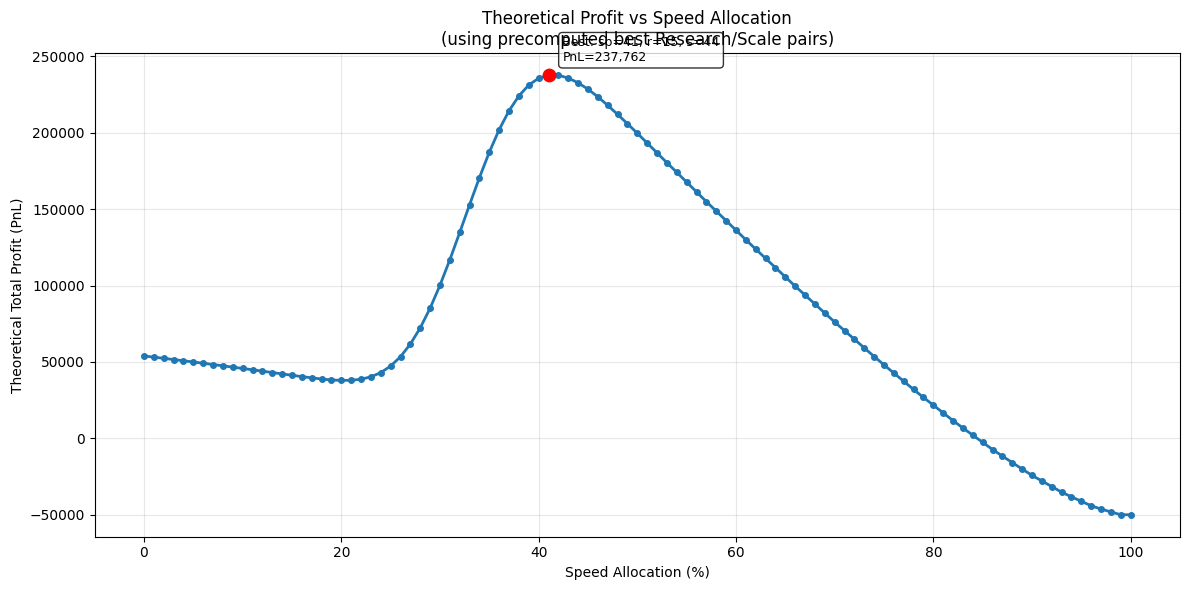

Sample points (speed, research, scale, pnl):
(  0, 23, 77, 53,926.19)
(  1, 23, 76, 53,162.65)
(  2, 23, 75, 52,383.68)
(  3, 23, 74, 51,589.30)
(  4, 22, 74, 50,791.92)
(  5, 22, 73, 49,985.35)
(  6, 22, 72, 49,163.56)
(  7, 22, 71, 48,326.57)
(  8, 22, 70, 47,474.40)
(  9, 21, 70, 46,617.79)
( 10, 21, 69, 45,755.61)
( 11, 21, 68, 44,879.12)
( 12, 21, 67, 43,989.23)
( 13, 21, 66, 43,087.86)
( 14, 20, 66, 42,188.44)
( 15, 20, 65, 41,301.15)
( 16, 20, 64, 40,428.44)
( 17, 20, 63, 39,595.56)
( 18, 20, 62, 38,845.10)
( 19, 19, 62, 38,254.71)
( 20, 19, 61, 37,933.51)
( 21, 19, 60, 38,018.06)
( 22, 19, 59, 38,712.78)
( 23, 19, 58, 40,278.39)
( 24, 18, 58, 43,035.72)
( 25, 18, 57, 47,330.18)
( 26, 18, 56, 53,477.58)
( 27, 18, 55, 61,753.97)
( 28, 18, 54, 72,324.30)
( 29, 17, 54, 85,211.56)
( 30, 17, 53, 100,229.28)
( 31, 17, 52, 116,945.96)
( 32, 17, 51, 134,760.90)
( 33, 17, 50, 152,934.56)
( 34, 16, 50, 170,716.52)
( 35, 16, 49, 187,333.67)
( 36, 16, 48, 202,084.05)
( 37, 16, 47, 214,469.9

In [15]:
# Theoretical total profit by speed allocation,
# paired with precomputed best (research, scale) combo for each total r+s.

# Build mapping: total (r+s) -> best (r, s)
best_points_by_total = {t: rs for t, rs in zip(totals, best_points)}

speed_allocs = np.arange(0, 101)
theoretical_profits = []
used_pairs = []

for sp_alloc in speed_allocs:
    total_rs = 100 - sp_alloc
    r_best, s_best = best_points_by_total[total_rs]

    # Use theoretical rank-based speed function from the alt mixture cell
    profit = pnl_with_speed(r_best, s_best, sp_alloc, speed_alt_mixture)

    theoretical_profits.append(profit)
    used_pairs.append((r_best, s_best))

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(speed_allocs, theoretical_profits, marker='o', linewidth=2, markersize=4)
ax.set_xlabel('Speed Allocation (%)')
ax.set_ylabel('Theoretical Total Profit (PnL)')
ax.set_title('Theoretical Profit vs Speed Allocation\n(using precomputed best Research/Scale pairs)')
ax.grid(True, alpha=0.3)

best_idx_speed = int(np.argmax(theoretical_profits))
best_sp = int(speed_allocs[best_idx_speed])
best_profit_speed = theoretical_profits[best_idx_speed]
best_r_speed, best_s_speed = used_pairs[best_idx_speed]

ax.scatter([best_sp], [best_profit_speed], color='red', s=80, zorder=5)
ax.annotate(
    f'Best: sp={best_sp}, r={best_r_speed}, s={best_s_speed}\nPnL={best_profit_speed:,.0f}',
    xy=(best_sp, best_profit_speed),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

print('Sample points (speed, research, scale, pnl):')
for i in range(0, 99):
    r_i, s_i = used_pairs[i]
    print(f'({speed_allocs[i]:3d}, {r_i:2d}, {s_i:2d}, {theoretical_profits[i]:,.2f})')

My gut says the optimal is likely to even be to the right of this point. Im watching sidemen charity match rn so dont feel like modeling this but I may aim for higher. Ideally around 50. Maybe others see this too so and ties are good so I'll do 50